# 02 — Demand Profile + Baseline KPIs + master_df_v2
**Depends on:** `data/master_df.parquet`

**Outputs:**
1. `data/demand_profile.csv` — orders per zip per week (for Sneha's K-Means + Anurag's Prophet)
2. `data/baseline_kpis.csv` — naive baseline metrics (the "before" numbers in our report)
3. `data/master_df_v2.parquet` — master_df + `demand_per_zip` + `cust_seller_dist_km`

---

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_parquet("../data/master_df.parquet")
print(f"Loaded master_df: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Columns: {df.columns.tolist()}")

Loaded master_df: 41,731 rows × 33 cols
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lon', 'price', 'freight_value', 'product_weight_g', 'n_items', 'product_id', 'product_category_name_english', 'seller_lat', 'seller_lon', 'seller_state', 'seller_city', 'seller_zip_code_prefix', 'review_score', 'payment_type', 'payment_value', 'delivery_days', 'days_late', 'order_value', 'is_return', 'return_rate_by_category']


## 1. Demand Profile — orders per zip per week

This feeds into:
- **Sneha:** demand-weighted K-Means (`sample_weight` parameter)
- **Anurag:** Prophet time-series forecasting per zone
- **Report:** demand heatmap visualisations

In [12]:
# Parse timestamps
df["order_date"] = pd.to_datetime(df["order_purchase_timestamp"])
df["year"] = df["order_date"].dt.isocalendar().year.astype(int)
df["week"] = df["order_date"].dt.isocalendar().week.astype(int)

# Weekly demand per zip
demand = (
    df.groupby(["customer_zip_code_prefix", "year", "week"], as_index=False)
    .agg(
        order_count=("order_id", "count"),
        total_value=("order_value", "sum"),
        total_weight_g=("product_weight_g", "sum"),
        return_count=("is_return", "sum"),
    )
)
demand["return_rate"] = demand["return_count"] / demand["order_count"]
demand = demand.sort_values(["customer_zip_code_prefix", "year", "week"])

print(f"Demand profile: {len(demand):,} rows")
print(f"Unique zips:    {demand['customer_zip_code_prefix'].nunique():,}")
print(f"Week range:     {demand[['year','week']].min().tolist()} → {demand[['year','week']].max().tolist()}")
demand.head(10)

Demand profile: 37,418 rows
Unique zips:    5,577
Week range:     [2016, 1] → [2018, 52]


,customer_zip_code_prefix,year,week,order_count,total_value,total_weight_g,return_count,return_rate
0,1003,2018,19,1,98.97,500.0,0,0.0
1,1004,2017,15,1,91.16,350.0,0,0.0
2,1004,2018,24,1,106.95,300.0,0,0.0
3,1005,2018,5,1,81.22,490.0,0,0.0
4,1005,2018,12,1,70.28,1400.0,0,0.0
5,1005,2018,14,1,162.85,275.0,0,0.0
6,1005,2018,25,1,44.29,650.0,0,0.0
7,1005,2018,32,1,134.83,100.0,0,0.0
8,1005,2018,33,1,77.25,100.0,0,0.0
9,1006,2017,34,1,601.55,2550.0,0,0.0


## 2. Zip-level demand summary (for K-Means weighting)

In [13]:
zip_summary = (
    df.groupby("customer_zip_code_prefix", as_index=False)
    .agg(
        demand_order_count=("order_id", "count"),
        demand_total_value=("order_value", "sum"),
        mean_lat=("customer_lat", "mean"),
        mean_lon=("customer_lon", "mean"),
    )
).sort_values("demand_order_count", ascending=False)

print(f"Unique zips: {len(zip_summary):,}")
print(f"\nTop 10 zips by order volume:")
print(zip_summary.head(10).to_string(index=False))

print(f"\nDemand distribution:")
print(zip_summary["demand_order_count"].describe().to_string())

Unique zips: 5,577

Top 10 zips by order volume:
 customer_zip_code_prefix  demand_order_count  demand_total_value   mean_lat   mean_lon
                    13212                  95            18046.23 -23.183004 -46.969228
                    13214                  82            13078.06 -23.160985 -46.917868
                    11030                  81            12815.28 -23.984798 -46.300849
                    11065                  80            10426.64 -23.966109 -46.342984
                    11740                  80            12338.12 -24.179856 -46.790496
                    13087                  76            13307.32 -22.854677 -47.051972
                    11680                  76            10303.16 -23.441645 -45.077753
                     7600                  75            10345.67 -23.322352 -46.589731
                    11075                  70             8109.51 -23.955266 -46.338259
                    13060                  68             8247.06 -22.9

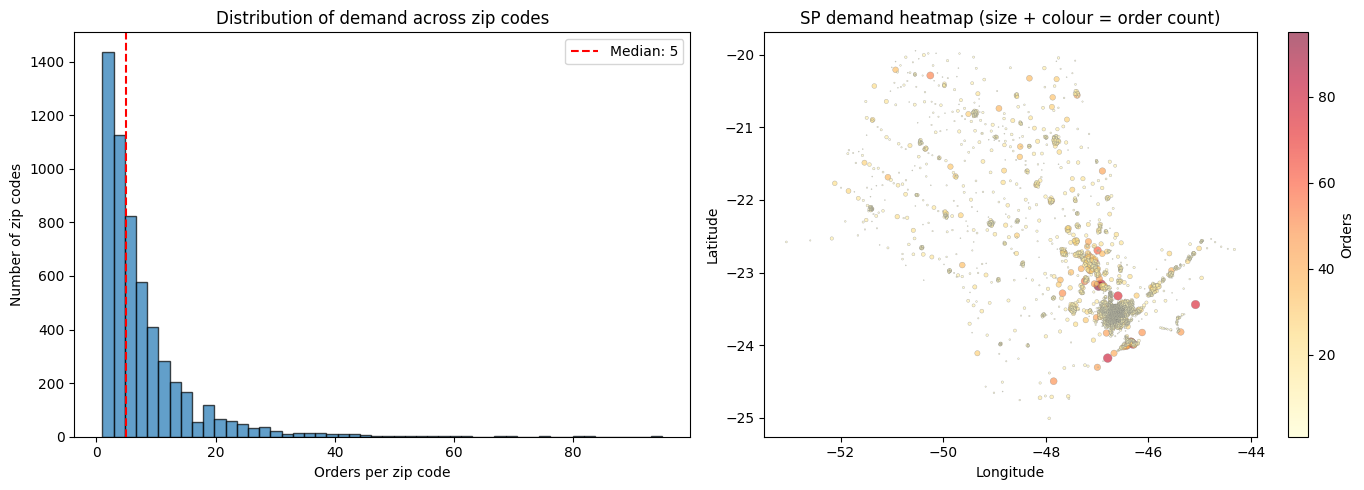

Saved → outputs/demand_distribution.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders per zip histogram
axes[0].hist(zip_summary["demand_order_count"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Orders per zip code")
axes[0].set_ylabel("Number of zip codes")
axes[0].set_title("Distribution of demand across zip codes")
axes[0].axvline(zip_summary["demand_order_count"].median(), color="red",
                linestyle="--", label=f"Median: {zip_summary['demand_order_count'].median():.0f}")
axes[0].legend()

# Demand scatter on map
sc = axes[1].scatter(
    zip_summary["mean_lon"], zip_summary["mean_lat"],
    c=zip_summary["demand_order_count"], cmap="YlOrRd",
    s=zip_summary["demand_order_count"] * 0.5, alpha=0.6, edgecolors="grey", linewidths=0.3,
)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("SP demand heatmap (size + colour = order count)")
plt.colorbar(sc, ax=axes[1], label="Orders")

plt.tight_layout()
plt.savefig("../outputs/demand_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/demand_distribution.png")

## 3. Baseline KPIs — the "before" numbers

These are the **naive scenario** metrics: every order ships directly from seller to customer.
No dark stores, no clustering, no route optimisation.

Our optimised solution's improvement % is measured against these exact numbers.

In [15]:
# Row-wise Haversine: customer → seller distance
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised Haversine distance in km."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

# Compute customer → seller distance
valid = df.dropna(subset=["seller_lat", "seller_lon"]).copy()
valid["cust_seller_dist_km"] = haversine_km(
    valid["customer_lat"].values, valid["customer_lon"].values,
    valid["seller_lat"].values, valid["seller_lon"].values,
)

print(f"Valid rows (have seller coords): {len(valid):,} / {len(df):,}")
print(f"\nCustomer → Seller distance (km):")
print(valid["cust_seller_dist_km"].describe().to_string())

Valid rows (have seller coords): 41,283 / 41,731

Customer → Seller distance (km):
count    41283.000000
mean       249.093776
std        278.010778
min          0.000000
25%         47.619969
50%        162.153391
75%        366.523690
max       2716.960514


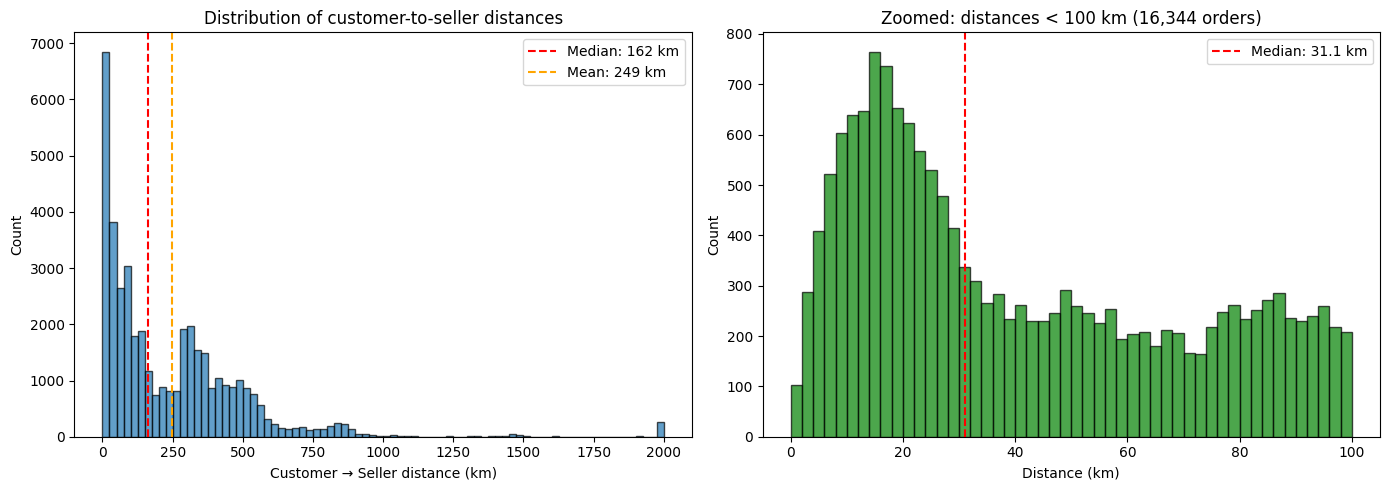

Saved → outputs/baseline_distance_distribution.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(valid["cust_seller_dist_km"].clip(upper=2000), bins=80, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Customer → Seller distance (km)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of customer-to-seller distances")
axes[0].axvline(valid["cust_seller_dist_km"].median(), color="red",
                linestyle="--", label=f"Median: {valid['cust_seller_dist_km'].median():.0f} km")
axes[0].axvline(valid["cust_seller_dist_km"].mean(), color="orange",
                linestyle="--", label=f"Mean: {valid['cust_seller_dist_km'].mean():.0f} km")
axes[0].legend()

# SP-only distances (zoom in)
sp_local = valid[valid["cust_seller_dist_km"] < 100]
axes[1].hist(sp_local["cust_seller_dist_km"], bins=50, edgecolor="black", alpha=0.7, color="green")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Zoomed: distances < 100 km ({len(sp_local):,} orders)")
axes[1].axvline(sp_local["cust_seller_dist_km"].median(), color="red",
                linestyle="--", label=f"Median: {sp_local['cust_seller_dist_km'].median():.1f} km")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/baseline_distance_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/baseline_distance_distribution.png")

In [17]:
baseline_kpis = {
    # Distance
    "mean_cust_seller_dist_km": round(valid["cust_seller_dist_km"].mean(), 2),
    "median_cust_seller_dist_km": round(valid["cust_seller_dist_km"].median(), 2),
    "p90_cust_seller_dist_km": round(valid["cust_seller_dist_km"].quantile(0.90), 2),
    "max_cust_seller_dist_km": round(valid["cust_seller_dist_km"].max(), 2),

    # Delivery time
    "mean_delivery_days": round(df["delivery_days"].mean(), 2),
    "median_delivery_days": round(df["delivery_days"].median(), 2),
    "mean_days_late": round(df["days_late"].mean(), 2),
    "pct_late_deliveries": round((df["days_late"] > 0).mean() * 100, 2),

    # Returns
    "return_rate_pct": round(df["is_return"].mean() * 100, 2),
    "total_returns": int(df["is_return"].sum()),
    "total_orders": len(df),

    # Cost
    "mean_order_value": round(df["order_value"].mean(), 2),
    "mean_freight_value": round(df["freight_value"].mean(), 2),
    "total_freight_revenue": round(df["freight_value"].sum(), 2),

    # Coverage (naive = none)
    "dark_store_coverage_pct": 0.0,
    "num_dark_stores": 0,

    # Entities
    "unique_customers": df["customer_id"].nunique(),
    "unique_zips": df["customer_zip_code_prefix"].nunique(),
}

print("=" * 55)
print("  BASELINE KPIs (Naive — No Dark Stores)")
print("=" * 55)
for k, v in baseline_kpis.items():
    print(f"  {k:>35s}: {v}")
print("=" * 55)

  BASELINE KPIs (Naive — No Dark Stores)
             mean_cust_seller_dist_km: 249.09
           median_cust_seller_dist_km: 162.15
              p90_cust_seller_dist_km: 531.65
              max_cust_seller_dist_km: 2716.96
                   mean_delivery_days: 8.3
                 median_delivery_days: 7.0
                       mean_days_late: -11.08
                  pct_late_deliveries: 4.36
                      return_rate_pct: 2.81
                        total_returns: 1174
                         total_orders: 41731
                     mean_order_value: 141.85
                   mean_freight_value: 17.37
                total_freight_revenue: 718508.66
              dark_store_coverage_pct: 0.0
                      num_dark_stores: 0
                     unique_customers: 41731
                          unique_zips: 5577


## 4. Enrich → `master_df_v2.parquet`

New columns added:
- `demand_per_zip` — total order count for this customer's zip code (K-Means weight)
- `cust_seller_dist_km` — Haversine distance from customer to seller (baseline metric)

In [18]:
# Add demand_per_zip
df = df.merge(
    zip_summary[["customer_zip_code_prefix", "demand_order_count"]],
    on="customer_zip_code_prefix", how="left",
)
df["demand_per_zip"] = df["demand_order_count"].fillna(1).astype(int)
df = df.drop(columns=["demand_order_count"], errors="ignore")

# Add cust_seller_dist_km
valid_mask = df["seller_lat"].notna() & df["seller_lon"].notna()
df.loc[valid_mask, "cust_seller_dist_km"] = haversine_km(
    df.loc[valid_mask, "customer_lat"].values,
    df.loc[valid_mask, "customer_lon"].values,
    df.loc[valid_mask, "seller_lat"].values,
    df.loc[valid_mask, "seller_lon"].values,
)

print(f"master_df_v2: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"New columns: demand_per_zip, cust_seller_dist_km")
print(f"Null cust_seller_dist_km: {df['cust_seller_dist_km'].isna().sum():,} (missing seller coords)")

master_df_v2: 41,731 rows × 38 cols
New columns: demand_per_zip, cust_seller_dist_km
Null cust_seller_dist_km: 448 (missing seller coords)


## 5. Save all outputs

In [19]:
from pathlib import Path
import json

Path("data").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

# 1. Demand profile
demand.to_csv("../data/demand_profile.csv", index=False)
print(f"✅ data/demand_profile.csv          ({len(demand):,} rows)")

# 2. Zip demand summary
zip_summary.to_csv("../data/zip_demand_summary.csv", index=False)
print(f"✅ data/zip_demand_summary.csv      ({len(zip_summary):,} rows)")

# 3. Baseline KPIs (CSV + JSON)
pd.DataFrame([baseline_kpis]).to_csv("../data/baseline_kpis.csv", index=False)
with open("../data/baseline_kpis.json", "w") as f:
    json.dump(baseline_kpis, f, indent=2)
print(f"✅ data/baseline_kpis.csv + .json")

# 4. master_df_v2
# Drop temporary columns before saving
drop_cols = ["order_date", "year", "week"]
df_save = df.drop(columns=[c for c in drop_cols if c in df.columns])
df_save.to_parquet("../data/master_df_v2.parquet", index=False)
print(f"✅ data/master_df_v2.parquet        ({len(df_save):,} rows × {df_save.shape[1]} cols)")

✅ data/demand_profile.csv          (37,418 rows)
✅ data/zip_demand_summary.csv      (5,577 rows)
✅ data/baseline_kpis.csv + .json
✅ data/master_df_v2.parquet        (41,731 rows × 35 cols)


## 6. Validation — reload and verify

In [20]:
v2 = pd.read_parquet("../data/master_df_v2.parquet")
assert "demand_per_zip" in v2.columns, "demand_per_zip missing!"
assert "cust_seller_dist_km" in v2.columns, "cust_seller_dist_km missing!"
assert "is_return" in v2.columns, "is_return missing!"
assert v2["customer_state"].unique().tolist() == ["SP"], "Non-SP rows!"
assert len(v2) == len(df_save), "Row count mismatch!"

print("✅ All assertions passed.")
print(f"   Columns ({v2.shape[1]}): {v2.columns.tolist()}")

# Quick check demand_per_zip
print(f"\n   demand_per_zip stats:")
print(f"   {v2['demand_per_zip'].describe().to_string()}")

# Confirm baseline KPIs reload
import json
with open("../data/baseline_kpis.json") as f:
    kpis = json.load(f)
print(f"\n   Baseline mean distance: {kpis['mean_cust_seller_dist_km']} km")
print(f"   Baseline return rate:   {kpis['return_rate_pct']}%")

✅ All assertions passed.
   Columns (35): ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lon', 'price', 'freight_value', 'product_weight_g', 'n_items', 'product_id', 'product_category_name_english', 'seller_lat', 'seller_lon', 'seller_state', 'seller_city', 'seller_zip_code_prefix', 'review_score', 'payment_type', 'payment_value', 'delivery_days', 'days_late', 'order_value', 'is_return', 'return_rate_by_category', 'demand_per_zip', 'cust_seller_dist_km']

   demand_per_zip stats:
   count    41731.000000
mean        16.167477
std         14.523898
min          1.000000
25%          6.000000
50%         12.000000
75%         21.000000
max         95.000000

   Baseline mean distance: 249.09 km
   Baseline return rate:   2.81%


## Day 2 Deliverables Checklist

| # | Output | Status |
|---|--------|--------|
| 1 | `data/demand_profile.csv` | ✅ |
| 2 | `data/zip_demand_summary.csv` | ✅ |
| 3 | `data/baseline_kpis.csv` + `.json` | ✅ |
| 4 | `data/master_df_v2.parquet` | ✅ |
| 5 | `outputs/demand_distribution.png` | ✅ |
| 6 | `outputs/baseline_distance_distribution.png` | ✅ |

**Share `master_df_v2.parquet` on Drive** — Sneha needs `demand_per_zip` for weighted K-Means.

**Next:** Day 3 → p-Median MILP validation + XGBoost return classifier start.